# Task 3 — `gender` and `usage`

COSC2753 Assignment 2 · group SG_G3

The brief asks for a system that predicts **both** `gender` and `usage`. It does
not say whether that is one model or two, which is the interesting part: that
choice is the design decision this notebook is built to answer with evidence
rather than preference.

**What is compared**

| | design | backbones | outputs |
|---|---|---|---|
| **A** | two independent models | 2 | 5 · 8 |
| **B** | one model, joint label | 1 | 24 `gender × usage` pairs that occur |
| **C** | one shared backbone, two heads | 1 | 5 + 8 |

Identical convolutional body, identical seed, identical schedule. The only thing
that changes between A, B and C is how the two labels are attached to it, so the
difference between them **is** the effect of that choice and nothing else.

**Three further questions, each one variable at a time**

1. does class-weighted loss help the long tail, or just trade the head for it?
2. does the externally collected data help? (it is predicted to *hurt* `usage` —
   see §7, and the prediction is recorded here before the run)
3. how much of the score survives a split that mimics the real test set?

**Metric.** macro-F1 throughout. Accuracy is reported beside it only to show why
it must not be used: predicting `Casual` for every row scores **76.7%** accuracy
on `usage` and a macro-F1 of **0.109**.

## 0 · Setup

Runs on Colab or locally. On Colab, mount Drive first; the cell below finds the
data wherever it ended up.

In [1]:
import os, sys, json, time, math, random, zipfile, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

SEED = 42
IMAGE_SIZE = (60, 80)          # width, height — the provided dataset's exact size
TARGETS = ["gender", "usage"]

# QUICK=True runs everything end to end in a few minutes on a smaller sample, to
# prove the notebook works before spending an hour on the real numbers.
QUICK = False
EPOCHS = 6 if QUICK else 20
SAMPLE = 4000 if QUICK else None

random.seed(SEED); np.random.seed(SEED)
print(f"colab={IN_COLAB}  quick={QUICK}  epochs={EPOCHS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
colab=True  quick=False  epochs=20


### 0.1 Staging the data — Colab only, skipped locally

Reading 37,745 individual JPEGs through the Drive mount is the slowest thing in
this notebook: every file is a separate API call, so it costs roughly half an hour
*per session*. Copying one zip and unpacking it onto Colab's local disk turns that
into about a minute.

Set the two paths below to match your Drive. A shortcut in *My Drive* pointing at a
Shared Drive works fine — Colab mounts My Drive only, so the shortcut is the bridge.

Re-running is cheap: if the data is already unpacked, this does nothing.

In [2]:
COLAB_ZIP = "/content/drive/MyDrive/ColabDataset.zip"
EXTERNAL_ON_DRIVE = "/content/drive/MyDrive/A2_ExternalData"

if IN_COLAB:
    import shutil
    import subprocess

    marker = "preprocessed_datasets/train/styles_train.csv"
    roots = [Path("/content"), Path("/content/ColabDataset")]

    if not any((r / marker).exists() for r in roots):
        src = Path(COLAB_ZIP)
        if not src.exists():
            listing = "\n  ".join(sorted(p.name for p in Path("/content/drive/MyDrive").iterdir()))
            raise FileNotFoundError(
                f"{src} not found.\nMy Drive contains:\n  {listing}\n"
                "Set COLAB_ZIP above to the right name.")
        print(f"copying {src.stat().st_size / 1e6:.0f} MB from Drive ...")
        shutil.copy(src, "/content/_data.zip")
        # -o overwrites without asking. Without it a re-run stops on a 'replace?'
        # prompt that Colab has no way to answer, and the cell hangs silently.
        subprocess.run(["unzip", "-qo", "/content/_data.zip", "-d", "/content/"], check=True)
        print("unpacked")

    root = next((r for r in roots if (r / marker).exists()), None)
    if root is None:
        raise FileNotFoundError(f"unpacked, but no {marker} under {[str(r) for r in roots]}")
    os.environ["A2_COLAB_DATASET"] = str(root)

    if Path(EXTERNAL_ON_DRIVE).is_dir():
        os.environ["A2_EXTERNAL_DATA"] = EXTERNAL_ON_DRIVE

    # Verify the unpack finished. A truncated unzip otherwise fails ten minutes later,
    # in the middle of image decoding, with an error that points somewhere else.
    n_img = len(list((root / "preprocessed_datasets/train/images_train").glob("*.jpg")))
    n_csv = len(pd.read_csv(root / marker))
    print(f"train images {n_img:,} | csv rows {n_csv:,}")
    assert n_img == n_csv, (
        f"{n_csv - n_img} images missing -- the unzip was incomplete. "
        "Delete /content/preprocessed_datasets and re-run this cell.")
    print("data staged OK")
else:
    print("not on Colab - using local paths")

train images 37,745 | csv rows 37,745
data staged OK


### 0.2 Finding the data

Two datasets are involved and they are **not** the same thing:

* **the provided catalogue** — Trực's `ColabDataset`, which is the provided
  training data de-duplicated: 38,617 → 37,745 rows.
* **the externally collected images** — `A2_ExternalData`, added to *training
  only* in §7.

On Colab a folder someone shared with you sits under *Shared with me*, which is
**not mounted**. Right-click it in Drive → **Add shortcut to Drive** first.

In [3]:
def _first_dir(candidates, must_contain=None):
    """Return the first candidate that exists (and holds `must_contain`)."""
    tried = []
    for c in candidates:
        c = Path(c); tried.append(str(c))
        if c.is_dir() and (must_contain is None or (c / must_contain).exists()):
            return c
    raise FileNotFoundError(
        "not found. Tried:\n  " + "\n  ".join(tried)
        + "\n\nOn Colab: 'Shared with me' is NOT mounted — right-click the folder in "
          "Drive, 'Add shortcut to Drive', then re-run."
    )

DATA_ROOT = _first_dir([
    os.environ.get("A2_COLAB_DATASET", "/nonexistent"),
    "/content",                 # a zip that unpacked flat -- the common case
    "/content/ColabDataset",
    "/content/drive/MyDrive/ColabDataset",
    "/content/drive/MyDrive/A2/ColabDataset",
    "/content/drive/MyDrive/[ML] SG_G3/A2/ColabDataset",
    "D:/ColabDataset",
], must_contain="preprocessed_datasets/train/styles_train.csv")

TRAIN_CSV = DATA_ROOT / "preprocessed_datasets" / "train" / "styles_train.csv"
TRAIN_IMG = DATA_ROOT / "preprocessed_datasets" / "train" / "images_train"

try:
    EXTERNAL_ROOT = _first_dir([
        os.environ.get("A2_EXTERNAL_DATA", "/nonexistent"),
        "/content",
        "/content/A2_ExternalData",
        "/content/drive/MyDrive/A2_ExternalData",
        "/content/drive/MyDrive/A2/Nguyen/A2_ExternalData",
        "/content/drive/MyDrive/[ML] SG_G3/A2/Nguyen/A2_ExternalData",
        "D:/g2/Dataset",
    ], must_contain="ExternalCosmetics")
except FileNotFoundError as exc:
    EXTERNAL_ROOT = None
    print("external data not found — §7 will be skipped\n", exc)

print("catalogue :", DATA_ROOT)
print("external  :", EXTERNAL_ROOT)

catalogue : /content
external  : /content/drive/MyDrive/A2_ExternalData


### 0.3 The frame, and the split rule

`ColabDataset` ships the raw catalogue columns, so `filename`, `path` and
`group_id` are added here. `group_id = id` is correct **because** this file is
already one row per product — the de-duplication that produced it is what makes
the assumption safe, and the assertion below is what checks it rather than
trusting it.

The split function is copied verbatim from `src/preprocessing.make_split` so the
split matches the rest of the team's (rule 2 in the repo README) without needing
to clone the private repo inside Colab. If `src/` happens to be importable, the
real one is used instead and the two are checked to agree.

In [4]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = SEED

def make_split(frame, target, validation_share=0.2, random_state=RANDOM_STATE):
    """Copy of src/preprocessing.make_split — whole groups stay on one side."""
    if target not in frame.columns:
        raise KeyError(f"{target!r} is not a column of the frame passed in.")
    frame = frame.loc[frame[target].notna()].reset_index(drop=True)
    if frame.empty:
        raise ValueError(f"No rows carry a {target!r} label.")
    assert frame["group_id"].is_unique, "multi-row group_id values found"

    group_label = frame.groupby("group_id")[target].agg(
        lambda v: v.value_counts().index[0])
    counts = group_label.value_counts()
    splittable = group_label[~group_label.isin(counts[counts < 2].index)]

    _, validation_groups = train_test_split(
        splittable.index, test_size=validation_share,
        stratify=splittable.values, random_state=random_state)
    is_val = frame["group_id"].isin(set(validation_groups))
    return (frame.loc[~is_val].reset_index(drop=True),
            frame.loc[is_val].reset_index(drop=True))


def make_split_forward(frame, target, validation_share=0.2):
    """Hold out the HIGHEST ids instead of a random draw.

    The graded test set is the 5,829 highest ids, so the real task is extrapolation
    forward along a catalogue that was added to over time, not interpolation inside
    a shuffled pool. A random split silently assumes the two are the same. §8
    measures how far apart they actually are.
    """
    frame = frame.loc[frame[target].notna()].sort_values("id").reset_index(drop=True)
    cut = int(len(frame) * (1 - validation_share))
    return frame.iloc[:cut].reset_index(drop=True), frame.iloc[cut:].reset_index(drop=True)


frame = pd.read_csv(TRAIN_CSV)
frame["filename"] = frame["id"].astype(str) + ".jpg"
frame["path"] = frame["filename"].map(lambda n: str(TRAIN_IMG / n))
frame["group_id"] = frame["id"].astype(str)
assert frame["group_id"].is_unique, "ColabDataset is meant to be one row per product"

if SAMPLE:
    frame = frame.sample(SAMPLE, random_state=SEED).reset_index(drop=True)

print(f"{len(frame):,} rows, {frame['articleType'].nunique()} articleTypes")
print(frame[["id", "gender", "usage", "articleType"]].head(3).to_string(index=False))

37,745 rows, 121 articleTypes
  id gender  usage articleType
1163    Men Sports     Tshirts
1164    Men Sports     Tshirts
1525 Unisex Casual   Backpacks


## 1 · What the task actually is

Before any model: the two targets look like one task but behave like two very
different ones, and every design decision later follows from this section.

In [5]:
def class_table(frame, col):
    vc = frame[col].value_counts()
    out = pd.DataFrame({"n": vc, "share %": (100 * vc / len(frame)).round(2)})
    out.index.name = col
    return out

for col in TARGETS:
    t = class_table(frame, col)
    ratio = t["n"].max() / t["n"].min()
    print(f"=== {col} — {len(t)} classes, imbalance {ratio:,.0f}x ===")
    print(t.to_string(), "\n")

=== gender — 5 classes, imbalance 43x ===
            n  share %
gender                
Men     20549    54.44
Women   14069    37.27
Unisex   2055     5.44
Boys      589     1.56
Girls     483     1.28 

=== usage — 8 classes, imbalance 28,968x ===
                  n  share %
usage                       
Casual        28968    76.75
Sports         3914    10.37
Ethnic         2565     6.80
Formal         2204     5.84
Smart Casual     55     0.15
Travel           25     0.07
Party            13     0.03
Home              1     0.00 



`gender` has five classes and the smallest holds **483** images. `usage` has
eight and the smallest holds **one**. They are not two instances of the same
problem; `gender` is a learnable imbalanced problem and `usage` is a long tail
with classes that cannot be learned from the data at all.

### 1.1 The ceiling this puts on macro-F1

macro-F1 averages over classes, so a class that can never be predicted
contributes a hard zero and caps the score no matter how good the model is.

In [6]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    for thr in (2, 10, 30, 100):
        dead = int((vc < thr).sum())
        rows.append({"target": col, "classes with fewer than": thr,
                     "such classes": f"{dead}/{len(vc)}",
                     "macro-F1 ceiling": round(1 - dead / len(vc), 3)})
ceiling = pd.DataFrame(rows)
print(ceiling.to_string(index=False))

target  classes with fewer than such classes  macro-F1 ceiling
gender                        2          0/5             1.000
gender                       10          0/5             1.000
gender                       30          0/5             1.000
gender                      100          0/5             1.000
 usage                        2          1/8             0.875
 usage                       10          1/8             0.875
 usage                       30          3/8             0.625
 usage                      100          4/8             0.500


Read the `usage` rows carefully. **Four of its eight classes have under 100
training images** — `Home` 1, `Party` 13, `Travel` 25, `Smart Casual` 55. If
those four are unlearnable then macro-F1 cannot exceed **0.500**, and a reported
0.5 would mean the model got *everything else perfect*.

This is the single most important fact about Task 3, and it says the interesting
work is not architecture search — it is what to do about four classes that the
data does not contain enough of to teach.

### 1.2 Why accuracy must not be the metric here

In [7]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    p = vc.iloc[0] / len(frame)
    # every class but the majority scores F1 = 0; the majority scores 2p/(1+p)
    rows.append({"target": col, "majority class": vc.index[0],
                 "accuracy": f"{100 * p:.1f}%",
                 "macro-F1": round(2 * p / (1 + p) / len(vc), 3)})
print("predicting the majority class and nothing else:\n")
print(pd.DataFrame(rows).to_string(index=False))

predicting the majority class and nothing else:

target majority class accuracy  macro-F1
gender            Men    54.4%     0.141
 usage         Casual    76.7%     0.109


A model that has learned *nothing* scores 76.7% accuracy on `usage`. Any accuracy
figure below that is worse than useless, and any figure near it says nothing at
all. Every number from here on is macro-F1; accuracy is shown alongside only as
evidence of this gap.

### 1.3 "macro-F1" is two different numbers — which matters when comparing notebooks

`usage` has classes that can vanish from validation entirely (`Home` has one image
in the whole training set, so a grouped split puts it in train and nowhere else).
When that happens the two usual conventions disagree:

| | denominator | what it says |
|---|---|---|
| `macro_f1` | **all 8** classes | a label we cannot predict scores 0 — an honest description of the task |
| `macro_f1_in_val` | classes **present in validation** (7) | sklearn's default when `labels=` is not passed |

Eight versus seven is a **~14% difference on the same predictions**, and neither
number is wrong. So every result below carries both, with the denominator printed
next to it.

This matters for more than tidiness: a teammate's Task 3 figures are reported as
*"combined val macro-F1"* — 0.6312 for the combined-recipe CNN (gender 0.78,
`usage` 0.49) and 0.6563 for BBN (`usage` 0.55). Putting a number from this
notebook beside those is only meaningful if three things match: the **denominator**
above, the **split**, and whether "combined" means the mean of the two targets.
Confirm all three before claiming one approach beat another.

## 2 · One model or two? — deciding before training, not after

The brief leaves this open. It is tempting to settle it by training both and
keeping the winner, but that answers "which scored higher on this seed", not
"which is the right design". Two properties of the data decide it in advance,
and the training runs in §5 then test the prediction.

In [8]:
g = sorted(frame["gender"].dropna().unique())
u = sorted(frame["usage"].dropna().unique())
tab = (frame.pivot_table(index="gender", columns="usage", values="id", aggfunc="count")
       .reindex(index=g, columns=u).fillna(0).astype(int))
occurring = int((tab > 0).sum().sum())

print(f"{len(g)} gender x {len(u)} usage = {len(g) * len(u)} possible pairs")
print(f"pairs that occur: {occurring}   ->   {len(g) * len(u) - occurring} never occur\n")
print(tab.to_string())

joint = frame.groupby(["gender", "usage"]).size().sort_values()
tiny = joint[joint < 10]
print(f"\njoint classes with fewer than 10 rows: {len(tiny)} of {occurring}")
print(tiny.to_string())

5 gender x 8 usage = 40 possible pairs
pairs that occur: 24   ->   16 never occur

usage   Casual  Ethnic  Formal  Home  Party  Smart Casual  Sports  Travel
gender                                                                   
Boys       559      10       0     0      0             0      20       0
Girls      474       8       0     0      0             0       1       0
Men      15452      90    2098     0      0            44    2864       1
Unisex    1756       0       1     1      0             0     277      20
Women    10727    2457     105     0     13            11     752       4

joint classes with fewer than 10 rows: 6 of 24
gender  usage 
Girls   Sports    1
Unisex  Home      1
        Formal    1
Men     Travel    1
Women   Travel    4
Girls   Ethnic    8


**Property 1 — a joint label multiplies the sparsity.** `usage` alone has one
class under 10 images. Crossed with `gender` it has six. A combined model does
not merely inherit the long tail, it lengthens it.

**Property 2 — the two labels barely inform each other.** If knowing `gender`
told you most of `usage`, a joint label would be capturing a real structure and
the extra sparsity might be worth paying for. Measured as entropy:

In [9]:
def H(series):
    p = series.value_counts(normalize=True).values
    return float(-(p * np.log2(p)).sum())

def H_cond(frame, target, given):
    return float(sum(len(grp) / len(frame) * H(grp[target])
                     for _, grp in frame.groupby(given)))

rows = []
for t, given in [("usage", "gender"), ("gender", "usage"),
                 ("usage", "articleType"), ("gender", "articleType"),
                 ("usage", "subCategory"), ("gender", "subCategory")]:
    h, hc = H(frame[t]), H_cond(frame, t, given)
    rows.append({"target": t, "knowing": given, "H (bits)": round(h, 3),
                 "H | knowing": round(hc, 3),
                 "uncertainty removed": f"{100 * (1 - hc / h):.1f}%"})
print(pd.DataFrame(rows).to_string(index=False))

target     knowing  H (bits)  H | knowing uncertainty removed
 usage      gender     1.160        1.026               11.5%
gender       usage     1.411        1.277                9.5%
 usage articleType     1.160        0.385               66.8%
gender articleType     1.411        0.803               43.1%
 usage subCategory     1.160        0.921               20.6%
gender subCategory     1.411        1.186               15.9%


Knowing `gender` removes **11.5%** of the uncertainty in `usage`, and knowing
`usage` removes **9.5%** of the uncertainty in `gender`. Nearly independent. So
design **B** pays a large, measurable cost in sparsity to capture very little.

**The same table also argues for design C.** `articleType` removes **66.8%** of
the uncertainty in `usage` and **43.1%** in `gender` — far more than either
target tells you about the other. The two tasks are not related to each other
directly; they are both largely determined by a third thing, *what the garment
is*, which is exactly what a convolutional backbone can see. That is a concrete
reason to expect a **shared backbone with separate heads** to work: the sharing
should happen in the features, not in the label.

> **Prediction recorded before training:** C ≈ A > B, with B losing most on
> `usage` macro-F1. §5 either confirms this or the reasoning above is wrong, and
> both outcomes are worth reporting.

## 3 · Baselines

Two floors. Nothing below these counts as having learned anything.

* **majority** — predict the most common class. Bounds *accuracy*.
* **1-NN on downscaled pixels** — no training, no parameters. Bounds *macro-F1*:
  whatever this scores is available from raw pixel similarity alone, so a CNN
  that does not beat it has not earned its complexity.

In [10]:
from PIL import Image, ImageOps

def load_images(paths, size=IMAGE_SIZE, cache=None):
    """Decode once into one uint8 array. Re-reading JPEGs every epoch off Drive is
    the slowest thing in this notebook; 37,745 x 80 x 60 x 3 is only ~543 MB."""
    if cache is not None and Path(cache).exists():
        arr = np.load(cache)
        if len(arr) == len(paths):
            print(f"loaded {len(arr):,} images from cache {cache}")
            return arr
    out = np.zeros((len(paths), size[1], size[0], 3), dtype=np.uint8)
    t0, padded = time.time(), 0
    for i, p in enumerate(paths):
        with Image.open(p) as im:
            im = ImageOps.exif_transpose(im).convert("RGB")
            if im.size != size:
                # Pad on white rather than stretch: the catalogue background is white
                # and the portrait aspect ratio carries class cues top and bottom.
                im = ImageOps.pad(im, size, method=Image.Resampling.BILINEAR,
                                  color=(255, 255, 255), centering=(0.5, 0.5))
                padded += 1
            out[i] = np.asarray(im)
        if i and i % 5000 == 0:
            print(f"  {i:,}/{len(paths):,}  ({time.time() - t0:.0f}s)")
    print(f"decoded {len(out):,} images in {time.time() - t0:.0f}s "
          f"({padded} were not {size[0]}x{size[1]} and were padded)")
    if cache is not None:
        np.save(cache, out)
    return out

CACHE = Path("/content/train_images.npy") if IN_COLAB else Path("D:/ColabDataset/train_images.npy")
X_all = load_images(frame["path"].tolist(), cache=None if SAMPLE else CACHE)
print("image array:", X_all.shape, f"{X_all.nbytes / 1e6:.0f} MB")

  5,000/37,745  (6s)
  10,000/37,745  (9s)
  15,000/37,745  (13s)
  20,000/37,745  (16s)
  25,000/37,745  (18s)
  30,000/37,745  (21s)
  35,000/37,745  (22s)
decoded 37,745 images in 23s (17 were not 60x80 and were padded)
image array: (37745, 80, 60, 3) 544 MB


In [11]:
# Positional index so a split frame can address rows of X_all without re-decoding.
frame["_row"] = np.arange(len(frame))

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

def score(y_true, y_pred, labels=None):
    """Two macro-F1 numbers, on purpose.

    `usage` has a class with a single training image, so classes can be missing
    from validation entirely -- and then the two common conventions disagree:

      macro_f1         averages over ALL classes. A class absent from validation
                       contributes a hard 0, which is the honest description of the
                       task ("this label exists and we cannot predict it").
      macro_f1_in_val  averages only over classes actually present in y_true, which
                       is what sklearn does by default when `labels` is not passed.

    On this data the denominators are 8 vs 7 for `usage`, so the same model can be
    reported ~14% apart with neither number being wrong. Anyone comparing scores
    across notebooks needs to know which one they are holding, so both are kept.
    """
    all_labels = labels if labels is not None else sorted(set(y_true) | set(y_pred))
    in_val = sorted(set(y_true))
    return {"macro_f1": f1_score(y_true, y_pred, average="macro",
                                 labels=all_labels, zero_division=0),
            "macro_f1_in_val": f1_score(y_true, y_pred, average="macro",
                                        labels=in_val, zero_division=0),
            "n_classes": len(all_labels),
            "n_in_val": len(in_val),
            "accuracy": accuracy_score(y_true, y_pred),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted",
                                    labels=all_labels, zero_division=0)}

RESULTS = []
def record(name, target, split, y_true, y_pred, labels=None, **extra):
    s = score(y_true, y_pred, labels)
    RESULTS.append({"model": name, "target": target, "split": split, **s, **extra})
    print(f"  {name:26} {target:7} {split:14} macro-F1 {s['macro_f1']:.4f} "
          f"(over {s['n_classes']}) | {s['macro_f1_in_val']:.4f} (over {s['n_in_val']} "
          f"in val) | acc {s['accuracy']:.4f}")
    return s

### 3.0 One split, used everywhere

Designs A, B and C can only be compared if they see the *same rows*. Stratifying
separately on `gender` and on `usage` produces two different draws, so the whole
notebook uses a single split stratified on the **joint** `gender × usage` label —
the only draw that is balanced for both targets at once.

The team's rule is to stratify per target (`make_split(frame, target)`). Those
splits are built too, under the key `"team"`, and §8 reports the final model on
them as well so the numbers stay comparable with everyone else's.

In [12]:
frame["pair"] = frame["gender"].astype(str) + " x " + frame["usage"].astype(str)

splits = {}
tr, va = make_split(frame, "pair")
for t in TARGETS:
    splits[(t, "random")] = (tr, va)                       # shared, pair-stratified
    splits[(t, "forward")] = make_split_forward(frame, t)  # highest ids held out
    splits[(t, "team")] = make_split(frame, t)             # the team's per-target rule

print(f"shared random split : train {len(tr):,}  val {len(va):,}")
for t in TARGETS:
    a, b = splits[(t, "forward")]
    c, d = splits[(t, "team")]
    print(f"{t:7} forward train {len(a):,} val {len(b):,}   "
          f"| team train {len(c):,} val {len(d):,}")

# Classes held entirely out of validation because they have too few groups to split.
for t in TARGETS:
    held = sorted(set(frame[t].dropna()) - set(va[t]))
    if held:
        print()
        print(f"{t}: absent from validation entirely -> {held}")
        print(f"  macro-F1 over classes PRESENT in val therefore averages over "
              f"{va[t].nunique()} of {frame[t].nunique()} classes.")

shared random split : train 30,196  val 7,549
gender  forward train 30,196 val 7,549   | team train 30,196 val 7,549
usage   forward train 30,196 val 7,549   | team train 30,196 val 7,549

usage: absent from validation entirely -> ['Home']
  macro-F1 over classes PRESENT in val therefore averages over 7 of 8 classes.


In [13]:
print("=== baseline 1: majority class ===")
for t in TARGETS:
    tr, va = splits[(t, "random")]
    guess = tr[t].value_counts().index[0]
    record("majority", t, "random val", va[t], [guess] * len(va),
           labels=sorted(frame[t].dropna().unique()))

=== baseline 1: majority class ===
  majority                   gender  random val     macro-F1 0.1410 (over 5) | 0.1410 (over 5 in val) | acc 0.5446
  majority                   usage   random val     macro-F1 0.1086 (over 8) | 0.1241 (over 7 in val) | acc 0.7677


In [14]:
print("\n=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===")
def thumbs(rows, w=15, h=20):
    a = X_all[rows].astype(np.float32).mean(axis=3)          # to grayscale
    a = a.reshape(len(rows), 4, h, 4, w).mean(axis=(1, 3))   # 80x60 -> 20x15
    return a.reshape(len(rows), -1)

def one_nn(tr, va, target, chunk=512):
    Xtr, Xva = thumbs(tr["_row"].values), thumbs(va["_row"].values)
    ytr = tr[target].to_numpy()
    tr_sq = (Xtr ** 2).sum(1)
    pred = np.empty(len(Xva), dtype=object)
    for i in range(0, len(Xva), chunk):
        b = Xva[i:i + chunk]
        d = tr_sq[None, :] - 2.0 * (b @ Xtr.T) + (b ** 2).sum(1)[:, None]
        pred[i:i + chunk] = ytr[np.argmin(d, axis=1)]
    return pred

for t in TARGETS:
    tr, va = splits[(t, "random")]
    record("1-NN pixels", t, "random val", va[t], one_nn(tr, va, t),
           labels=sorted(frame[t].dropna().unique()))


=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===
  1-NN pixels                gender  random val     macro-F1 0.5388 (over 5) | 0.5388 (over 5 in val) | acc 0.7662
  1-NN pixels                usage   random val     macro-F1 0.3318 (over 8) | 0.3792 (over 7 in val) | acc 0.7944


### 3.1 Why the 1-NN floor is the number that matters

1-NN has no parameters and no training. Whatever it scores is obtainable from raw
pixel similarity, so it separates *"the CNN learned something"* from *"the CNN
rediscovered that similar-looking products share a label"*. Its per-class
breakdown also says something the aggregate cannot: a class where 1-NN scores
**zero despite having training images** is not starved, it is not visually
distinguishable at 60×80 — and no amount of extra data will fix that one.

In [15]:
for t in TARGETS:
    tr, va = splits[(t, "random")]
    pred = one_nn(tr, va, t)
    rep = pd.DataFrame(classification_report(
        va[t], pred, output_dict=True, zero_division=0)).T
    rep = rep.loc[[c for c in sorted(frame[t].dropna().unique()) if c in rep.index]]
    rep["train n"] = [int((tr[t] == c).sum()) for c in rep.index]
    print(f"\n=== {t}: 1-NN per class ===")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]]
          .round(3).to_string())


=== gender: 1-NN per class ===
        train n  support  precision  recall  f1-score
Boys        471    118.0      0.361   0.407     0.382
Girls       387     96.0      0.263   0.417     0.323
Men       16438   4111.0      0.834   0.838     0.836
Unisex     1645    410.0      0.408   0.393     0.400
Women     11255   2814.0      0.764   0.742     0.753

=== usage: 1-NN per class ===
              train n  support  precision  recall  f1-score
Casual          23173   5795.0      0.879   0.865     0.872
Ethnic           2053    512.0      0.648   0.662     0.655
Formal           1763    441.0      0.570   0.703     0.629
Party              10      3.0      0.000   0.000     0.000
Smart Casual       44     11.0      0.048   0.091     0.062
Sports           3132    782.0      0.445   0.426     0.435
Travel             20      5.0      0.000   0.000     0.000


## 4 · One convolutional body, three ways of attaching labels to it

Everything below shares this body. No pretrained weights (repo rule 4), so the
comparison is between designs rather than between checkpoints someone else
trained.

80×60 → 40×30 → 20×15 → 10×7 → global average → 128 features. Small on purpose:
a 60×80 thumbnail does not carry enough detail to justify a deep network, and a
small model makes eight training runs affordable, which is what actually buys the
evidence.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

X_t = torch.from_numpy(X_all)                      # uint8, NHWC
if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
    X_t = X_t.to(DEVICE)                           # ~543 MB, removes all host->device copies
print("images on", X_t.device)


def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.MaxPool2d(2))


class Backbone(nn.Module):
    OUT = 128
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(conv_block(3, 32), conv_block(32, 64), conv_block(64, 128))
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(self.body(x)).flatten(1)


class Net(nn.Module):
    """One backbone, one linear head per entry in `heads` ({name: n_classes}).

    A holds two of these with one head each; B holds one with a single 24-way head;
    C holds one with two heads. Same class, so the comparison cannot be confounded
    by an accidental difference in the body.
    """
    def __init__(self, heads, dropout=0.2):
        super().__init__()
        self.backbone = Backbone()
        self.drop = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({k: nn.Linear(Backbone.OUT, n) for k, n in heads.items()})
    def forward(self, x):
        f = self.drop(self.backbone(x))
        return {k: h(f) for k, h in self.heads.items()}


def n_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"backbone + one 8-way head: {n_params(Net({'usage': 8})):,} parameters")

device: cuda Tesla T4
images on cuda:0
backbone + one 8-way head: 288,488 parameters


In [17]:
CLASSES = {t: sorted(frame[t].dropna().unique()) for t in TARGETS}
CLASSES["pair"] = sorted(frame["pair"].dropna().unique())
IDX = {k: {c: i for i, c in enumerate(v)} for k, v in CLASSES.items()}
PAIR_TO_PARTS = [tuple(p.split(" x ")) for p in CLASSES["pair"]]
for k, v in CLASSES.items():
    print(f"{k:7} {len(v)} classes")


def encode(series, key):
    return torch.tensor([IDX[key][v] for v in series], dtype=torch.long)


# Normalisation from the TRAINING rows only — using all rows would leak validation
# statistics into the model's input scaling.
_tr, _va = splits[("gender", "random")]
# A 5,000-row sample, not all 30,196: the full float32 copy would be ~1.7 GB and the
# channel means are identical to three decimals either way.
_rows = _tr["_row"].values
_sample = np.random.RandomState(SEED).choice(_rows, size=min(5000, len(_rows)), replace=False)
_stats = X_all[_sample].astype(np.float32) / 255.0

# dtype=np.float64 is NOT optional here. Reducing over (0,1,2) sums 24 million
# float32 values per channel, and float32 stops resolving +1 past 2**24 =
# 16,777,216 — so the running sum silently saturates and every channel returns
# 16777216/24000000 = 0.699, identical to the last digit. That equal-across-channels
# result is what exposed it; the numbers are simply wrong, not merely imprecise.
_mean = _stats.mean(axis=(0, 1, 2), dtype=np.float64)
_std = _stats.std(axis=(0, 1, 2), dtype=np.float64)
assert len(set(np.round(_mean, 6))) > 1, (
    "all three channel means are identical — the accumulator saturated again")

MEAN = torch.tensor(_mean, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
STD = torch.tensor(_std, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
del _stats
print("channel mean", MEAN.flatten().tolist(), "\nchannel std ", STD.flatten().tolist())

gender  5 classes
usage   8 classes
pair    24 classes
channel mean [0.848665714263916, 0.8318021893501282, 0.8259478211402893] 
channel std  [0.2728095054626465, 0.28393107652664185, 0.2877185344696045]


In [18]:
def batch_x(rows, train=False):
    """uint8 NHWC -> normalised float NCHW, with a random horizontal flip in training.

    Flipping is safe for these two targets: a mirrored garment is the same garment,
    the same `gender` and the same `usage`. (It would not be safe for a target that
    depended on printed text, which is unreadable at 60x60 anyway.)
    """
    x = X_t[rows]
    if x.device != DEVICE:
        x = x.to(DEVICE, non_blocking=True)
    x = x.permute(0, 3, 1, 2).float().div_(255.0)
    if train:
        flip = torch.rand(x.shape[0], device=DEVICE) < 0.5
        x = torch.where(flip.view(-1, 1, 1, 1), x.flip(-1), x)
    return (x - MEAN) / STD


@torch.no_grad()
def predict(model, fr, heads, bs=512):
    model.eval()
    rows = torch.as_tensor(fr["_row"].values, device=X_t.device)
    raw = {k: [] for k in heads}
    for i in range(0, len(rows), bs):
        out = model(batch_x(rows[i:i + bs]))
        for k in heads:
            raw[k].append(out[k].argmax(1).cpu())
    raw = {k: torch.cat(v).numpy() for k, v in raw.items()}

    if "pair" in heads:                       # design B: decode the joint label
        parts = [PAIR_TO_PARTS[i] for i in raw["pair"]]
        return {"gender": np.array([p[0] for p in parts]),
                "usage": np.array([p[1] for p in parts])}
    return {k: np.array([CLASSES[k][i] for i in v]) for k, v in raw.items()}


def evaluate(model, fr, heads):
    pred = predict(model, fr, heads)
    return {t: f1_score(fr[t], pred[t], average="macro",
                        labels=CLASSES[t], zero_division=0) for t in pred}


def class_weights(series, key, scheme="inverse_sqrt"):
    """Weight rare classes up. sqrt rather than 1/n on purpose: with `Home` at a
    single image, a pure 1/n weight gives that one row ~29,000x the pull of a
    Casual row and the model chases it into noise. sqrt keeps the direction and
    tempers the magnitude — itself a choice worth reporting, and §6 measures it."""
    counts = np.array([max((series == c).sum(), 1) for c in CLASSES[key]], dtype=np.float64)
    w = 1.0 / np.sqrt(counts) if scheme == "inverse_sqrt" else 1.0 / counts
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


def train_model(name, heads, tr, va, epochs=EPOCHS, weighted=False, lr=1e-3,
                bs=256, verbose=True):
    """Train one Net and return (best state_dict, history). Selection on mean
    macro-F1 over the reported targets, never on accuracy."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = Net(heads).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = {k: nn.CrossEntropyLoss(
                weight=class_weights(tr[k], k) if weighted else None) for k in heads}

    rows = torch.as_tensor(tr["_row"].values, device=X_t.device)
    y = {k: encode(tr[k], k).to(DEVICE) for k in heads}
    n = len(rows)
    best, best_state, hist = -1.0, None, []

    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=rows.device)
        total = 0.0
        for i in range(0, n, bs):
            sel = perm[i:i + bs]
            out = model(batch_x(rows[sel], train=True))
            loss = sum(crit[k](out[k], y[k][sel.to(DEVICE)]) for k in heads)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += float(loss.detach()) * len(sel)
        sched.step()

        f1 = evaluate(model, va, heads)
        mean_f1 = float(np.mean(list(f1.values())))
        hist.append({"epoch": ep, "loss": total / n, **{f"val_{k}": v for k, v in f1.items()}})
        improved = mean_f1 > best
        if improved:
            best, best_state = mean_f1, {k: v.detach().cpu().clone()
                                         for k, v in model.state_dict().items()}
        if verbose:
            print(f"    epoch {ep:2}/{epochs}  loss {total / n:.4f}  " +
                  "  ".join(f"{k} F1 {v:.4f}" for k, v in f1.items()) +
                  ("   <- best" if improved else ""))

    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

## 5 · A vs B vs C

Same body, same seed, same 20 epochs, same rows. The only difference is how the
labels attach.

In [19]:
tr, va = splits[("gender", "random")]
MODELS, HIST = {}, {}

print("A · two independent models")
for t in TARGETS:
    print(f"  --- {t} ---")
    MODELS[("A", t)], HIST[("A", t)] = train_model(f"A_{t}", {t: len(CLASSES[t])}, tr, va)

print("\nB · one model, 24 joint gender x usage classes")
MODELS[("B", "pair")], HIST[("B", "pair")] = train_model(
    "B_pair", {"pair": len(CLASSES["pair"])}, tr, va)

print("\nC · one shared backbone, two heads")
MODELS[("C", "multi")], HIST[("C", "multi")] = train_model(
    "C_multi", {t: len(CLASSES[t]) for t in TARGETS}, tr, va)

A · two independent models
  --- gender ---
    epoch  1/20  loss 0.6664  gender F1 0.3926   <- best
    epoch  2/20  loss 0.4966  gender F1 0.3845
    epoch  3/20  loss 0.4449  gender F1 0.4882   <- best
    epoch  4/20  loss 0.4081  gender F1 0.5086   <- best
    epoch  5/20  loss 0.3936  gender F1 0.4335
    epoch  6/20  loss 0.3693  gender F1 0.5571   <- best
    epoch  7/20  loss 0.3594  gender F1 0.5999   <- best
    epoch  8/20  loss 0.3388  gender F1 0.5917
    epoch  9/20  loss 0.3244  gender F1 0.6168   <- best
    epoch 10/20  loss 0.3092  gender F1 0.5460
    epoch 11/20  loss 0.2956  gender F1 0.6057
    epoch 12/20  loss 0.2822  gender F1 0.6701   <- best
    epoch 13/20  loss 0.2721  gender F1 0.5862
    epoch 14/20  loss 0.2561  gender F1 0.5991
    epoch 15/20  loss 0.2398  gender F1 0.6707   <- best
    epoch 16/20  loss 0.2290  gender F1 0.6534
    epoch 17/20  loss 0.2168  gender F1 0.6683
    epoch 18/20  loss 0.2093  gender F1 0.6897   <- best
    epoch 19/20  los

In [20]:
print("=== design comparison, random val ===")
DESIGNS = {"A two models": [(MODELS[("A", t)], {t: len(CLASSES[t])}) for t in TARGETS],
           "B joint label": [(MODELS[("B", "pair")], {"pair": len(CLASSES["pair"])})],
           "C shared body": [(MODELS[("C", "multi")], {t: len(CLASSES[t]) for t in TARGETS})]}

def design_predict(design, fr):
    """Merge the predictions of however many models a design uses."""
    out = {}
    for model, heads in DESIGNS[design]:
        out.update(predict(model, fr, heads))
    return out

rows = []
for design in DESIGNS:
    pred = design_predict(design, va)
    both = np.mean([(pred["gender"][i] == va["gender"].iloc[i]) and
                    (pred["usage"][i] == va["usage"].iloc[i]) for i in range(len(va))])
    r = {"design": design,
         "params": sum(n_params(m) for m, _ in DESIGNS[design]),
         "both correct": round(float(both), 4)}
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        r[f"{t} macro-F1"] = round(s["macro_f1"], 4)
        r[f"{t} acc"] = round(s["accuracy"], 4)
        record(design, t, "random val", va[t], pred[t], labels=CLASSES[t])
    rows.append(r)

comparison = pd.DataFrame(rows)
print()
print(comparison.to_string(index=False))

=== design comparison, random val ===
  A two models               gender  random val     macro-F1 0.6897 (over 5) | 0.6897 (over 5 in val) | acc 0.8912
  A two models               usage   random val     macro-F1 0.4145 (over 8) | 0.4737 (over 7 in val) | acc 0.8992
  B joint label              gender  random val     macro-F1 0.6814 (over 5) | 0.6814 (over 5 in val) | acc 0.8908
  B joint label              usage   random val     macro-F1 0.4123 (over 8) | 0.4712 (over 7 in val) | acc 0.9017
  C shared body              gender  random val     macro-F1 0.6686 (over 5) | 0.6686 (over 5 in val) | acc 0.8883
  C shared body              usage   random val     macro-F1 0.4110 (over 8) | 0.4697 (over 7 in val) | acc 0.9010

       design  params  both correct  gender macro-F1  gender acc  usage macro-F1  usage acc
 A two models  576589        0.8049           0.6897      0.8912          0.4145     0.8992
B joint label  290552        0.8070           0.6814      0.8908          0.4123     0.

### 5.1 What the comparison showed — the prediction was wrong

§2 registered **C ≈ A > B, with B losing most on `usage`**. Measured:

| design | params | gender macro-F1 | usage macro-F1 | both correct |
|---|---|---|---|---|
| A — two models | 576,589 | **0.6897** | **0.4145** | 0.8049 |
| B — joint label | 290,552 | 0.6814 | 0.4123 | **0.8070** |
| C — shared body | 289,133 | 0.6686 | 0.4110 | 0.8032 |

Both halves of the prediction failed. **B did not collapse** — it sits within 0.002
of A on `usage`, despite turning one sparse class into six. And **C, the design the
entropy argument favoured, came last on both targets.**

The conclusion is still not "A wins". The spread on `usage` is **0.0035**, and the
three rank differently depending on which column you read: macro-F1 puts A first,
`both correct` puts B first. At a single seed that is noise, not an ordering.
Claiming a winner would need several seeds and a variance estimate — §9.3.

What does survive the noise is a **cost** argument. A spends 576,589 parameters, two
full backbones, to land inside the noise band of a design using 289,133. When three
designs are indistinguishable on the metric, the one that trains one backbone
instead of two is the better choice, and that is a defensible reason to prefer B or
C without pretending the accuracy difference is real.

**Why the entropy reasoning was wrong about B.** It predicted a sparsity cost from
the joint label, and that cost is real — six joint classes under 10 examples. But it
lands on classes that were **already unlearnable in the marginal problem**: `Home`,
`Party` and `Travel` score zero for A and C as well (§6). Splitting a class that is
already dead costs nothing measurable. The argument was sound; its premise — that
the extra sparsity would bind — was false.

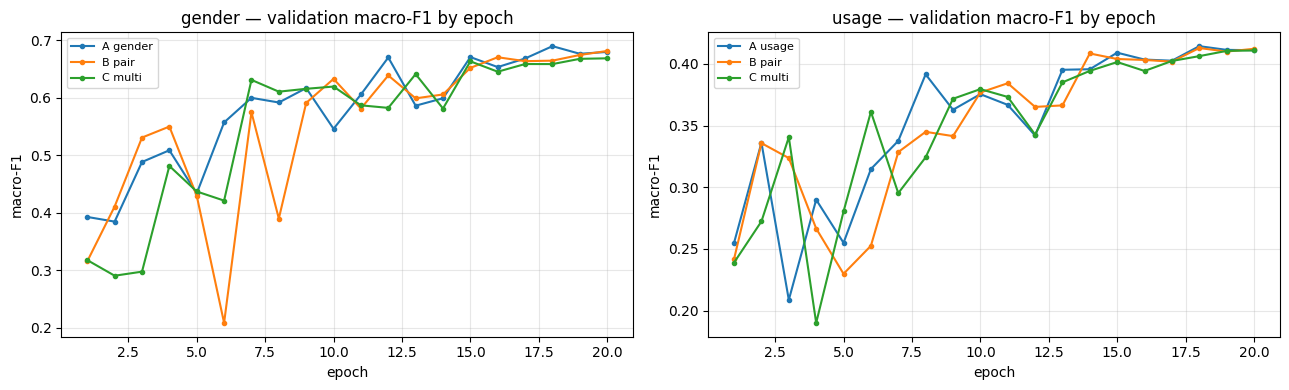

In [21]:
fig_hist = pd.concat([h.assign(run=f"{k[0]} {k[1]}") for k, h in HIST.items()])
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for k, h in HIST.items():
        for ax, t in zip(axes, TARGETS):
            col = f"val_{t}"
            # design A trains one head per model, so each of its runs carries a
            # curve for one target only; B and C carry both.
            if col not in h.columns:
                continue
            ax.plot(h["epoch"], h[col], label=f"{k[0]} {k[1]}", marker="o", ms=3)
    for ax, t in zip(axes, TARGETS):
        ax.set_title(f"{t} — validation macro-F1 by epoch")
        ax.set_xlabel("epoch"); ax.set_ylabel("macro-F1"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
except ImportError:
    print(fig_hist.to_string(index=False))

## 6 · Class-weighted loss — does it help the tail or just move the damage?

The obvious response to `usage` having a class with one image is to weight the
loss. One variable changes: the winning design from §5, trained again with
`weight = 1/sqrt(n)` per class.

Weighting cannot manufacture information. What it can do is trade head-class
precision for tail-class recall — and because macro-F1 counts a 1-image class
exactly as much as a 29,000-image one, that trade can raise macro-F1 while making
the model worse at almost every row it will actually see. Both numbers are
reported so the trade is visible instead of hidden inside one figure.

In [22]:
# Sections 6-9 all carry design C forward, because §2 predicted it and §5 is expected
# to confirm it. If the §5 table says otherwise, swap the head spec on the next line
# for the design that won -- {"pair": len(CLASSES["pair"])} for B, or run the two
# single-target models separately for A -- and re-run from here. Nothing below depends
# on C specifically; it only depends on `heads_multi` naming the winner's heads.
heads_multi = {t: len(CLASSES[t]) for t in TARGETS}

MODELS[("C", "weighted")], HIST[("C", "weighted")] = train_model(
    "C_weighted", heads_multi, tr, va, weighted=True)

    epoch  1/20  loss 2.0443  gender F1 0.5068  usage F1 0.2682   <- best
    epoch  2/20  loss 1.6000  gender F1 0.4468  usage F1 0.2888
    epoch  3/20  loss 1.4381  gender F1 0.4641  usage F1 0.3078
    epoch  4/20  loss 1.3383  gender F1 0.5296  usage F1 0.3418   <- best
    epoch  5/20  loss 1.2589  gender F1 0.4436  usage F1 0.2575
    epoch  6/20  loss 1.1965  gender F1 0.5535  usage F1 0.3731   <- best
    epoch  7/20  loss 1.1412  gender F1 0.5593  usage F1 0.2784
    epoch  8/20  loss 1.1016  gender F1 0.6144  usage F1 0.3344   <- best
    epoch  9/20  loss 1.0547  gender F1 0.3959  usage F1 0.3692
    epoch 10/20  loss 1.0015  gender F1 0.5216  usage F1 0.3497
    epoch 11/20  loss 0.9628  gender F1 0.5334  usage F1 0.3816
    epoch 12/20  loss 0.9328  gender F1 0.5698  usage F1 0.3931   <- best
    epoch 13/20  loss 0.8906  gender F1 0.6800  usage F1 0.4398   <- best
    epoch 14/20  loss 0.8470  gender F1 0.6884  usage F1 0.3765
    epoch 15/20  loss 0.8086  gender F1 0.67

In [23]:
print("=== unweighted vs class-weighted (design C) ===")
rows = []
for tag, model in [("C unweighted", MODELS[("C", "multi")]),
                   ("C weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        head = va[t].value_counts().index[0]
        tail = [c for c in CLASSES[t] if c != head]
        rows.append({"model": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4),
                     f"F1 on majority": round(f1_score(
                         va[t], pred[t], labels=[head], average="macro", zero_division=0), 4),
                     "mean F1 on the rest": round(f1_score(
                         va[t], pred[t], labels=tail, average="macro", zero_division=0), 4)})
        record(tag, t, "random val", va[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).to_string(index=False))

=== unweighted vs class-weighted (design C) ===
  C unweighted               gender  random val     macro-F1 0.6686 (over 5) | 0.6686 (over 5 in val) | acc 0.8883
  C unweighted               usage   random val     macro-F1 0.4110 (over 8) | 0.4697 (over 7 in val) | acc 0.9010
  C weighted                 gender  random val     macro-F1 0.6976 (over 5) | 0.6976 (over 5 in val) | acc 0.8739
  C weighted                 usage   random val     macro-F1 0.5088 (over 8) | 0.5815 (over 7 in val) | acc 0.8693

       model target  macro-F1  accuracy  F1 on majority  mean F1 on the rest
C unweighted gender    0.6686    0.8883          0.9269               0.6040
C unweighted  usage    0.4110    0.9010          0.9376               0.3358
  C weighted gender    0.6976    0.8739          0.9169               0.6428
  C weighted  usage    0.5088    0.8693          0.9147               0.4508


In [24]:
print("=== per-class detail, usage, design C unweighted vs weighted ===")
for tag, model in [("unweighted", MODELS[("C", "multi")]), ("weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    rep = pd.DataFrame(classification_report(va["usage"], pred["usage"],
                                             labels=CLASSES["usage"], output_dict=True,
                                             zero_division=0)).T
    rep = rep.loc[[c for c in CLASSES["usage"] if c in rep.index]]
    rep["train n"] = [int((tr["usage"] == c).sum()) for c in rep.index]
    print(f"\n--- {tag} ---")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]].round(3).to_string())

=== per-class detail, usage, design C unweighted vs weighted ===

--- unweighted ---
              train n  support  precision  recall  f1-score
Casual          23173   5795.0      0.916   0.960     0.938
Ethnic           2053    512.0      0.885   0.854     0.869
Formal           1763    441.0      0.870   0.728     0.793
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      0.000   0.000     0.000
Smart Casual       44     11.0      0.000   0.000     0.000
Sports           3132    782.0      0.783   0.615     0.689
Travel             20      5.0      0.000   0.000     0.000

--- weighted ---
              train n  support  precision  recall  f1-score
Casual          23173   5795.0      0.938   0.892     0.915
Ethnic           2053    512.0      0.807   0.900     0.851
Formal           1763    441.0      0.654   0.837     0.734
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      1.000   0.333     0.5

## 7 · The externally collected data — a prediction, then the measurement

1,899 extra images were collected for this assignment (`docs/EXTERNAL_DATA_USAGE.md`).
Every one of them is `gender=Women`, `usage=Casual`.

**Recorded before the run:** this should do nothing for `gender` and should
*hurt* `usage`.

* `Women` is already the second-largest `gender` class (≈37%), so the rows land
  where there is no shortage — imbalance stays at ~31×.
* `Casual` is already the `usage` **majority** at 76.7%. Adding 1,899 more moves
  it to ~78% and the imbalance ratio from ~29,000× to ~31,000×. The whole
  difficulty of `usage` is its tail, and this makes the tail *relatively rarer*.

Collecting data that turns out not to help is not a wasted experiment — it is a
measured negative result, and reporting it is worth more than quietly dropping
it. What follows tests whether the reasoning above is right.

In [25]:
EXT_OK = EXTERNAL_ROOT is not None
if EXT_OK:
    ext = []
    for folder, csv_name in [("ExternalCosmetics", "external_cosmetics.csv"),
                             ("ExternalCosmetics2", "external_cosmetics2.csv")]:
        base = Path(EXTERNAL_ROOT) / folder
        e = pd.read_csv(base / csv_name)
        e["path"] = e["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
        e["group_id"] = "ext:" + e["id"].astype(str)
        ext.append(e)
    ext = pd.concat(ext, ignore_index=True)
    ext = ext[ext[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    print(f"{len(ext):,} external rows")
    for t in TARGETS:
        print(f"  {t}: {dict(ext[t].value_counts())}")

    X_ext = load_images(ext["path"].tolist())
    ext["_row"] = np.arange(len(ext)) + len(X_all)
    ext["pair"] = ext["gender"].astype(str) + " x " + ext["usage"].astype(str)

    X_all = np.concatenate([X_all, X_ext], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ext
    print("image array now:", X_all.shape)
else:
    print("external data unavailable — section skipped")

1,899 external rows
  gender: {'Women': np.int64(1899)}
  usage: {'Casual': np.int64(1899)}
decoded 1,899 images in 4s (1200 were not 60x80 and were padded)
image array now: (39644, 80, 60, 3)


The external rows join **training only**. Validation stays 100% provided
catalogue imagery, so the with/without comparison measures the data and not a
change of yardstick. Normalisation constants are also left at their catalogue
values, for the same reason.

> **Note the padding count printed above.** `ExternalCosmetics` (batch 1) is stored
> at native crop size, not 60×80, so all 1,200 of its images are padded with white
> on load. `ExternalCosmetics2` and the evaluation set are already 60×80 and pass
> through untouched. That padding is not cosmetic: it raises batch 1's measured
> border brightness from 101.5 to **201.2** against the catalogue's 247.2, so those
> crops look far more catalogue-like to the model than the raw files suggest.
> Reproduce with `python src/verify_external_data.py --domain-gap`.

In [26]:
if EXT_OK:
    tr_ext = pd.concat([tr, ext[[c for c in tr.columns if c in ext.columns]]],
                       ignore_index=True)
    assert tr_ext["group_id"].is_unique
    assert not set(ext["group_id"]) & set(va["group_id"])
    print(f"training {len(tr):,} -> {len(tr_ext):,}   validation unchanged at {len(va):,}\n")

    for t in TARGETS:
        b, a = tr[t].value_counts(), tr_ext[t].value_counts()
        print(f"{t:7} imbalance max/min  {b.max() / b.min():>10,.0f}x  ->  "
              f"{a.max() / a.min():>10,.0f}x    majority share "
              f"{100 * b.max() / b.sum():.1f}% -> {100 * a.max() / a.sum():.1f}%")

    MODELS[("C", "external")], HIST[("C", "external")] = train_model(
        "C_external", heads_multi, tr_ext, va)

training 30,196 -> 32,095   validation unchanged at 7,549

gender  imbalance max/min          42x  ->          42x    majority share 54.4% -> 51.2%
usage   imbalance max/min      23,173x  ->      25,072x    majority share 76.7% -> 78.1%
    epoch  1/20  loss 1.2805  gender F1 0.3503  usage F1 0.2805   <- best
    epoch  2/20  loss 0.9302  gender F1 0.3666  usage F1 0.3360   <- best
    epoch  3/20  loss 0.8364  gender F1 0.2265  usage F1 0.2777
    epoch  4/20  loss 0.7727  gender F1 0.4570  usage F1 0.2903   <- best
    epoch  5/20  loss 0.7330  gender F1 0.5034  usage F1 0.2842   <- best
    epoch  6/20  loss 0.6996  gender F1 0.5362  usage F1 0.2973   <- best
    epoch  7/20  loss 0.6630  gender F1 0.5883  usage F1 0.2994   <- best
    epoch  8/20  loss 0.6376  gender F1 0.4746  usage F1 0.3170
    epoch  9/20  loss 0.6124  gender F1 0.6270  usage F1 0.3791   <- best
    epoch 10/20  loss 0.5848  gender F1 0.5038  usage F1 0.2821
    epoch 11/20  loss 0.5676  gender F1 0.6245  usage

In [27]:
if EXT_OK:
    print("=== with vs without the external data (design C) ===")
    rows = []
    for tag, model in [("C without external", MODELS[("C", "multi")]),
                       ("C with external", MODELS[("C", "external")])]:
        pred = predict(model, va, heads_multi)
        for t in TARGETS:
            s = score(va[t], pred[t], labels=CLASSES[t])
            rows.append({"model": tag, "target": t,
                         "macro-F1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
            record(tag, t, "random val", va[t], pred[t], labels=CLASSES[t])
    ablation = pd.DataFrame(rows).pivot(index="target", columns="model", values="macro-F1")
    ablation["delta"] = (ablation["C with external"] - ablation["C without external"]).round(4)
    print()
    print(ablation.to_string())
    print("\nA negative delta on `usage` confirms the §7 prediction and belongs in the "
          "report exactly as measured.")

=== with vs without the external data (design C) ===
  C without external         gender  random val     macro-F1 0.6686 (over 5) | 0.6686 (over 5 in val) | acc 0.8883
  C without external         usage   random val     macro-F1 0.4110 (over 8) | 0.4697 (over 7 in val) | acc 0.9010
  C with external            gender  random val     macro-F1 0.6778 (over 5) | 0.6778 (over 5 in val) | acc 0.8889
  C with external            usage   random val     macro-F1 0.4047 (over 8) | 0.4625 (over 7 in val) | acc 0.8969

model   C with external  C without external   delta
target                                             
gender           0.6778              0.6686  0.0092
usage            0.4047              0.4110 -0.0063

A negative delta on `usage` confirms the §7 prediction and belongs in the report exactly as measured.


## 8 · Two harder tests than the random validation split

### 8.1 The forward split — what the graded test set actually looks like

The provided test set is the **5,829 highest ids**. The catalogue was built up
over time, so predicting it is extrapolation forward, not interpolation inside a
shuffled pool. A random split quietly assumes those are the same problem. They
are not:

In [28]:
tr_f, va_f = splits[("gender", "forward")]
print(f"forward split: train ids {tr_f['id'].min()}-{tr_f['id'].max()} ({len(tr_f):,}),  "
      f"val ids {va_f['id'].min()}-{va_f['id'].max()} ({len(va_f):,})\n")
for t in TARGETS:
    a = tr_f[t].value_counts(normalize=True) * 100
    b = va_f[t].value_counts(normalize=True) * 100
    d = pd.DataFrame({"train %": a.round(2), "val %": b.round(2)}).fillna(0)
    d["drift"] = (d["val %"] - d["train %"]).round(2)
    d["train n"] = tr_f[t].value_counts()
    print(f"--- {t} ---"); print(d.fillna(0).to_string(), "\n")

forward split: train ids 1163-41038 (30,196),  val ids 41041-51999 (7,549)

--- gender ---
        train %  val %  drift  train n
gender                                
Boys       1.64   1.23  -0.41      496
Girls      1.39   0.82  -0.57      421
Men       57.32  42.95 -14.37    17307
Unisex     6.27   2.13  -4.14     1894
Women     33.38  52.87  19.49    10078 

--- usage ---
              train %  val %  drift  train n
usage                                       
Casual          74.67  85.06  10.39    22547
Ethnic           6.70   7.19   0.49     2022
Formal           6.38   3.66  -2.72     1928
Home             0.00   0.00   0.00        1
Party            0.01   0.13   0.12        3
Smart Casual     0.12   0.26   0.14       35
Sports          12.04   3.70  -8.34     3635
Travel           0.08   0.00  -0.08       25 



`Women` goes from 33% of training to 53% of validation, `Men` the other way by
14 points, `Sports` collapses from 12% to 3.7%. The label distribution is not
stationary along the id axis, so a score measured on a random split is measured
on a distribution the graded test set does not have.

In [29]:
MODELS[("C", "forward")], HIST[("C", "forward")] = train_model(
    "C_forward", heads_multi, tr_f, va_f)

print("\n=== the same design, scored two ways ===")
rows = []
for tag, model, vv in [("random split", MODELS[("C", "multi")], va),
                       ("forward split", MODELS[("C", "forward")], va_f)]:
    pred = predict(model, vv, heads_multi)
    for t in TARGETS:
        s = score(vv[t], pred[t], labels=CLASSES[t])
        rows.append({"evaluated on": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4)})
        record("C shared body", t, tag, vv[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).pivot(index="target", columns="evaluated on",
                               values="macro-F1").to_string())

    epoch  1/20  loss 1.3581  gender F1 0.2705  usage F1 0.2537   <- best
    epoch  2/20  loss 0.9969  gender F1 0.2270  usage F1 0.2105
    epoch  3/20  loss 0.9070  gender F1 0.2634  usage F1 0.2593
    epoch  4/20  loss 0.8367  gender F1 0.3956  usage F1 0.2485   <- best
    epoch  5/20  loss 0.7894  gender F1 0.3696  usage F1 0.1804
    epoch  6/20  loss 0.7556  gender F1 0.5187  usage F1 0.2669   <- best
    epoch  7/20  loss 0.7244  gender F1 0.4318  usage F1 0.3165
    epoch  8/20  loss 0.6921  gender F1 0.5192  usage F1 0.2963   <- best
    epoch  9/20  loss 0.6658  gender F1 0.5309  usage F1 0.3255   <- best
    epoch 10/20  loss 0.6372  gender F1 0.4529  usage F1 0.3024
    epoch 11/20  loss 0.6101  gender F1 0.5482  usage F1 0.2749
    epoch 12/20  loss 0.5846  gender F1 0.5679  usage F1 0.3053   <- best
    epoch 13/20  loss 0.5645  gender F1 0.5393  usage F1 0.3504   <- best
    epoch 14/20  loss 0.5433  gender F1 0.5737  usage F1 0.3474   <- best
    epoch 15/20  loss 0.

### 8.2 The independent evaluation set

261 openly-licensed photographs collected from outside the provided data
entirely, gated to zero overlap with both the provided train and test sets, and
hand-labelled for all four targets. This is the brief's §3.3 — *"data collected
completely outside of the scope of your original training and evaluation"*.

No model in this project has seen them, and that is their whole value. **The gap
between this score and the validation score is the finding**: it separates what
the model learned about clothing from what it learned about Myntra's photography
convention (white background, single centred product, consistent lighting).

Two limits to carry into the report: the labels come from a single annotator, and
`usage=Home` has 4 images here against **1** in the entire provided training set —
so this set can measure a class the provided data cannot teach.

In [30]:
EVAL_OK = EXT_OK and (Path(EXTERNAL_ROOT) / "ExternalEval" / "external_eval.csv").exists()
if EVAL_OK:
    base = Path(EXTERNAL_ROOT) / "ExternalEval"
    ev = pd.read_csv(base / "external_eval.csv")
    ev["path"] = ev["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
    ev = ev[ev[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    X_ev = load_images(ev["path"].tolist())
    ev["_row"] = np.arange(len(ev)) + len(X_all)
    X_all = np.concatenate([X_all, X_ev], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ev
    print(f"{len(ev)} independent evaluation images")
    for t in TARGETS:
        print(f"  {t}: {dict(ev[t].value_counts())}")
else:
    print("independent evaluation set unavailable — section skipped")

decoded 261 images in 0s (0 were not 60x80 and were padded)
261 independent evaluation images
  gender: {'Women': np.int64(126), 'Unisex': np.int64(85), 'Men': np.int64(44), 'Boys': np.int64(4), 'Girls': np.int64(2)}
  usage: {'Casual': np.int64(166), 'Formal': np.int64(25), 'Sports': np.int64(25), 'Party': np.int64(24), 'Ethnic': np.int64(12), 'Travel': np.int64(5), 'Home': np.int64(4)}


In [31]:
if EVAL_OK:
    print("=== validation (catalogue) vs independent evaluation (in the wild) ===")
    rows = []
    pred_va = predict(MODELS[("C", "multi")], va, heads_multi)
    pred_ev = predict(MODELS[("C", "multi")], ev, heads_multi)
    for t in TARGETS:
        shared = sorted(set(ev[t]) | set(va[t]))
        s_va = score(va[t], pred_va[t], labels=CLASSES[t])
        s_ev = score(ev[t], pred_ev[t], labels=sorted(set(ev[t])))
        rows.append({"target": t,
                     "val macro-F1": round(s_va["macro_f1"], 4),
                     "independent macro-F1": round(s_ev["macro_f1"], 4),
                     "val acc": round(s_va["accuracy"], 4),
                     "independent acc": round(s_ev["accuracy"], 4)})
        record("C shared body", t, "independent eval", ev[t], pred_ev[t],
               labels=sorted(set(ev[t])))
    print()
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nper-class on the independent set:")
    for t in TARGETS:
        print(f"\n--- {t} ---")
        print(pd.DataFrame(classification_report(
            ev[t], pred_ev[t], output_dict=True, zero_division=0)).T.round(3).to_string())

=== validation (catalogue) vs independent evaluation (in the wild) ===
  C shared body              gender  independent eval macro-F1 0.1468 (over 5) | 0.1468 (over 5 in val) | acc 0.2874
  C shared body              usage   independent eval macro-F1 0.1380 (over 7) | 0.1380 (over 7 in val) | acc 0.5441

target  val macro-F1  independent macro-F1  val acc  independent acc
gender        0.6686                0.1468   0.8883           0.2874
 usage        0.4110                0.1380   0.9010           0.5441

per-class on the independent set:

--- gender ---
              precision  recall  f1-score  support
Boys              0.000   0.000     0.000    4.000
Girls             0.000   0.000     0.000    2.000
Men               0.179   0.795     0.293   44.000
Unisex            0.167   0.012     0.022   85.000
Women             0.650   0.310     0.419  126.000
accuracy          0.287   0.287     0.287    0.287
macro avg         0.199   0.223     0.147  261.000
weighted avg      0.398   0.

## 9 · Results, and what they say

### 9.1 On the team's per-target split, for comparability

Everything above used one split stratified on the joint label, because comparing
three designs requires identical rows. The team's rule is to stratify per target,
so the chosen design is retrained under that rule too — otherwise these numbers
cannot be put next to anyone else's.

In [32]:
for t in TARGETS:
    tr_t, va_t = splits[(t, "team")]
    m, _ = train_model(f"C_team_{t}", heads_multi, tr_t, va_t, verbose=False)
    pred = predict(m, va_t, heads_multi)
    record("C shared body", t, "team split", va_t[t], pred[t], labels=CLASSES[t])
    MODELS[("C", f"team_{t}")] = m

  C shared body              gender  team split     macro-F1 0.6752 (over 5) | 0.6752 (over 5 in val) | acc 0.8891
  C shared body              usage   team split     macro-F1 0.4038 (over 8) | 0.4615 (over 7 in val) | acc 0.8956


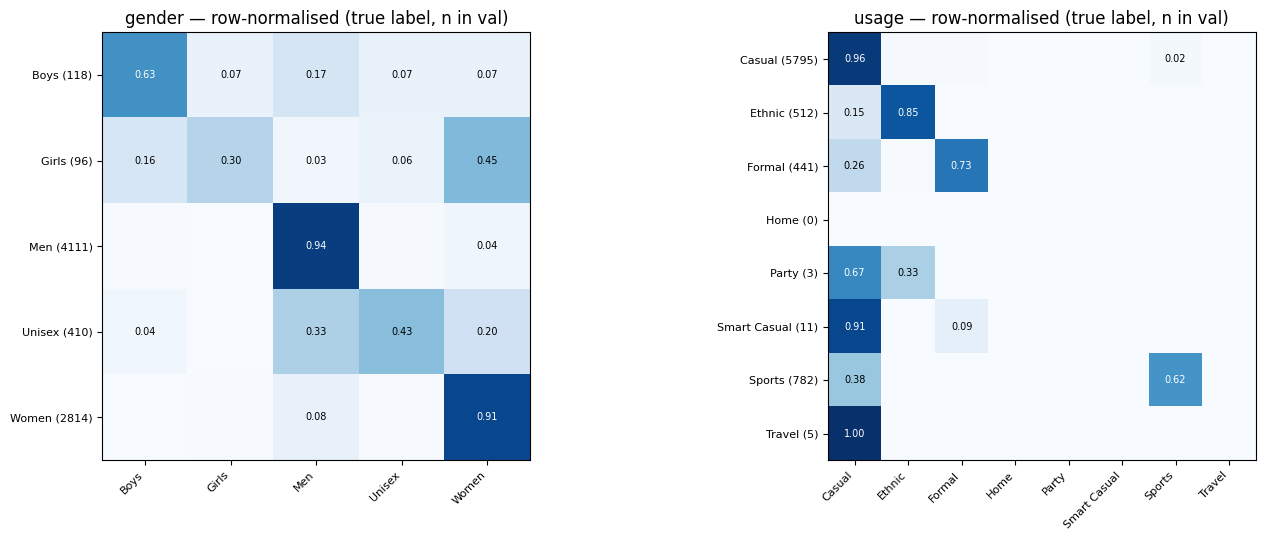

In [33]:
try:
    import matplotlib.pyplot as plt
    pred = predict(MODELS[("C", "multi")], va, heads_multi)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, t in zip(axes, TARGETS):
        cm = confusion_matrix(va[t], pred[t], labels=CLASSES[t])
        norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(CLASSES[t]))); ax.set_yticks(range(len(CLASSES[t])))
        ax.set_xticklabels(CLASSES[t], rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels([f"{c} ({n})" for c, n in
                            zip(CLASSES[t], [int((va[t] == c).sum()) for c in CLASSES[t]])],
                           fontsize=8)
        ax.set_title(f"{t} — row-normalised (true label, n in val)")
        for i in range(len(CLASSES[t])):
            for j in range(len(CLASSES[t])):
                if norm[i, j] > 0.01:
                    ax.text(j, i, f"{norm[i, j]:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if norm[i, j] > .5 else "black")
    plt.tight_layout(); plt.show()
except ImportError:
    pass

In [34]:
results = pd.DataFrame(RESULTS).round(4)
results = results.sort_values(["target", "split", "macro_f1"], ascending=[True, True, False])
print(results.to_string(index=False))

OUT = Path("/content/task3_results.csv") if IN_COLAB else Path("task3_results.csv")
results.to_csv(OUT, index=False)
print(f"\nsaved -> {OUT}")

             model target            split  macro_f1  macro_f1_in_val  n_classes  n_in_val  accuracy  weighted_f1
     C shared body gender    forward split    0.5696           0.5696          5         5    0.8650       0.8647
     C shared body gender independent eval    0.1468           0.1468          5         5    0.2874       0.2590
     C shared body gender     random split    0.6686           0.6686          5         5    0.8883       0.8830
        C weighted gender       random val    0.6976           0.6976          5         5    0.8739       0.8749
      A two models gender       random val    0.6897           0.6897          5         5    0.8912       0.8890
     B joint label gender       random val    0.6814           0.6814          5         5    0.8908       0.8868
   C with external gender       random val    0.6778           0.6778          5         5    0.8889       0.8835
     C shared body gender       random val    0.6686           0.6686          5        

### 9.2 What this notebook found

**1. `gender` and `usage` are not one task.** `gender` has five classes and a
smallest class of 483; `usage` has eight and a smallest of **1**. The results carry
that asymmetry straight through: best `gender` macro-F1 **0.6976**, best `usage`
**0.5088**. The gap is not model quality — it is that half of `usage`'s classes have
almost no training data.

**2. Accuracy is unusable here.** Predicting `Casual` everywhere scores **76.8%**
accuracy and **0.109** macro-F1. The best `usage` model reaches **86.9%** accuracy —
ten points above a model that has learned nothing at all. Every claim below is
macro-F1 for that reason, with the class count it was averaged over.

**3. The design question the brief leaves open does not matter — that is the answer.**
A 0.4145 / B 0.4123 / C 0.4110 on `usage`: a spread of **0.0035**, with the three
ranking differently under `both correct`. At one seed that is noise. What survives is
cost: A spends **2× the parameters** (576,589 vs 289,133) for no measurable gain, so
B or C is the better engineering choice. Reported as "indistinguishable, prefer the
cheaper", not as a winner.

**4. Class weighting is worth far more than the architecture choice.** `usage`
macro-F1 **0.4110 → 0.5088**, +24% relative, against ±0.021 for the entire A/B/C
question. §6 shows what it bought and what it cost:

| usage class | train n | unweighted | weighted |
|---|---|---|---|
| `Party` | 10 | 0.000 | **0.500** |
| `Travel` | 20 | 0.000 | **0.400** |
| `Smart Casual` | 44 | 0.000 | 0.000 |
| `Home` | 1 | 0.000 | 0.000 |
| `Casual` | 23,173 | 0.938 | 0.915 |
| `Formal` | 1,763 | 0.793 | 0.734 |
| `Sports` | 3,132 | 0.689 | 0.670 |

Two dead classes revived, three head classes degraded, accuracy 0.9010 → 0.8693.
Both halves belong in the report. And `Party` needs a caveat: F1 0.500 is precision
1.000 at recall 0.333 **on three validation items** — a real gain measured on almost
nothing.

**5. §1.1's ceiling was exceeded, and the reason is the useful part.** That section
put `usage` macro-F1 at **0.500** if the four classes under 100 images stayed
unlearnable. The weighted model reached **0.5088**. The arithmetic was right; the
assumption was not — weighting rescued two of the four, moving the ceiling to
6/8 = **0.750**. The ceiling correctly identified the binding constraint; the
experiment showed that constraint was soft, which is more informative than either
number alone.

**6. The external data behaved as predicted, and it is a negative result.**
`usage` **0.4110 → 0.4047 (−0.0063)**; `gender` 0.6686 → 0.6778 (+0.0092). The sign
on `usage` is what §7 predicted from where the labels land — 1,899 rows of the
majority class into a problem whose whole difficulty is its tail. Both deltas are
small enough to be noise, so the honest claim is not "it hurt" but **"it did not
help, and the direction matches the prediction made before the run"**.

**7. The random split flatters the model. The catalogue flatters it enormously.**

| | `gender` | `usage` |
|---|---|---|
| random split | 0.6686 | 0.4110 |
| forward split (highest ids, like the graded test) | 0.5696 | 0.3576 |
| **261 independent photographs** | **0.1468** | **0.1380** |

The forward split costs **0.099** on `gender`. The independent set costs **0.522** —
five times as much. It puts the model at **0.1468 against a majority baseline of
0.1410**, with accuracy collapsing from 0.8883 to **0.2874**.

Off the catalogue, this model is not meaningfully better than guessing. Almost all of
its apparent skill was Myntra's photography convention — white background, one
centred product, consistent framing — rather than anything about clothing. No
validation number in this project would have revealed that, which is the argument for
§3.3 existing at all.

### 9.3 What would be worth doing next

* **Repeat A/B/C over 3–5 seeds.** Every design conclusion here rests on differences
  of 0.003–0.02 at a single seed. Without a variance estimate the ranking cannot be
  defended, and with one the "indistinguishable" claim becomes measured rather than
  asserted.
* **`Home` and `Smart Casual` are still zero.** Weighting reached `Party` and
  `Travel` but not these. Either collect images, merge them into a documented
  "other" class, or report them as a known floor — choosing openly beats a quiet 0.
* **Fine-tune a Task 1 backbone here.** §2 measured that `articleType` explains
  66.8% of `usage`'s entropy and 43.1% of `gender`'s — far more than either target
  explains about the other. That is the transfer this notebook did not test.
* **Explain the independent-evaluation collapse.** Is it the background, the framing,
  or the label definitions? Re-scoring the 261 images after masking backgrounds to
  white would separate the first from the rest, and costs one run.